<Figure size 800x800 with 0 Axes>

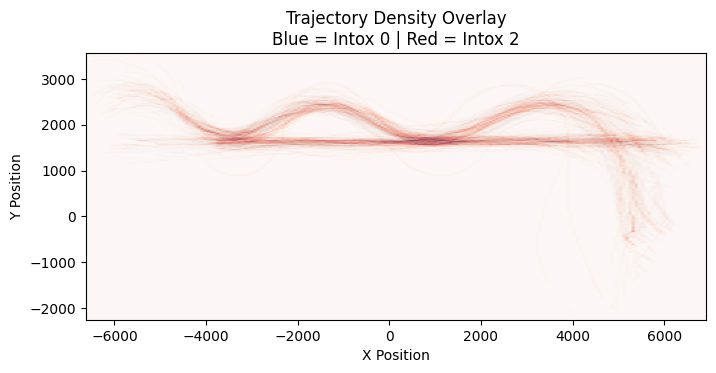

In [32]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Folder containing the CSV files
data_folder = Path(r"C:\Users\amoh\Desktop\microtox\eventhallen\signals")

# Vehicle mapping
vehicle_map = {
    0: "bike",
    1: "voi_scooter",
    2: "small_scooter"
}


# Titles
plt.figure(figsize=(8,8))
points = {0: {"x": [], "y": []}, 2: {"x": [], "y": []}}


# Loop through all csv files
for file in data_folder.glob("*.csv"):

    name = file.stem
    parts = name.split("_")

    participant = int(parts[0][1:])
    intox_level = int(parts[1][1:])
    vehicle = int(parts[2][1:])
    repetition = int(parts[3][1:])
    task = parts[4]

    # Only VOI scooter
    if vehicle != 1 or task not in ["straight", "slalom"]:
        continue
    if intox_level not in [0, 2]:
        continue

    df = pd.read_csv(file)

    if "VOI_Frame X" not in df.columns or "VOI_Frame Y" not in df.columns:
        print(f"Skipping {file.name} (missing columns)")
        continue

    x = -df["VOI_Frame X"]
    y = -df["VOI_Frame Y"]
    valid = ~(x.isna() | y.isna())

    x = x[valid]
    y = y[valid]
    
    
    points[intox_level]["x"].extend(x)
    points[intox_level]["y"].extend(y)
    # x = x - x.iloc[0]
    # y = y - y.iloc[0]
    
    # color = "red" if intox_level == 0 else "blue"

    # Plot on the corresponding intox panel
x0 = np.array(points[0]["x"])
y0 = np.array(points[0]["y"])

x2 = np.array(points[2]["x"])
y2 = np.array(points[2]["y"])

# remove invalid values
xmin = min(x0.min(), x2.min())
xmax = max(x0.max(), x2.max())

ymin = min(y0.min(), y2.min())
ymax = max(y0.max(), y2.max())

bins = 200

H0, xedges, yedges = np.histogram2d(x0, y0, bins=bins, range=[[xmin,xmax],[ymin,ymax]])
H2, _, _ = np.histogram2d(x2, y2, bins=[xedges,yedges])

# transpose for plotting
H0 = H0.T
H2 = H2.T

# -------------------------
# PLOT OVERLAY
# -------------------------
plt.figure(figsize=(8,8))

plt.imshow(
    H0,
    extent=[xmin,xmax,ymin,ymax],
    origin="lower",
    cmap="Blues",
    alpha=0.6
)

plt.imshow(
    H2,
    extent=[xmin,xmax,ymin,ymax],
    origin="lower",
    cmap="Reds",
    alpha=0.6
)

plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.title("Trajectory Density Overlay\nBlue = Intox 0 | Red = Intox 2")

plt.gca().set_aspect("equal")

plt.show()

In [4]:
df = pd.read_csv(r"C:\Users\amoh\Desktop\microtox\eventhallen\signals\P028_L0_V1_R0_straight.csv")
df.head()

# find columns whose name contains “imu”
imu_cols = [col for col in df.columns if 'imu' in col.lower()]

print("IMU columns:", imu_cols)
print("any IMU column?", bool(imu_cols))   

IMU columns: ['IMU-1 Gyr.X', 'IMU-1 Gyr.Y', 'IMU-1 Gyr.Z', 'IMU-1 Axl.X', 'IMU-1 Axl.Y', 'IMU-1 Axl.Z', 'IMU-1 q.w', 'IMU-1 q.i', 'IMU-1 q.j', 'IMU-1 q.k', 'IMU-2 Gyr.X', 'IMU-2 Gyr.Y', 'IMU-2 Gyr.Z', 'IMU-2 Axl.X', 'IMU-2 Axl.Y', 'IMU-2 Axl.Z', 'IMU-2 q.w', 'IMU-2 q.i', 'IMU-2 q.j', 'IMU-2 q.k']
any IMU column? True


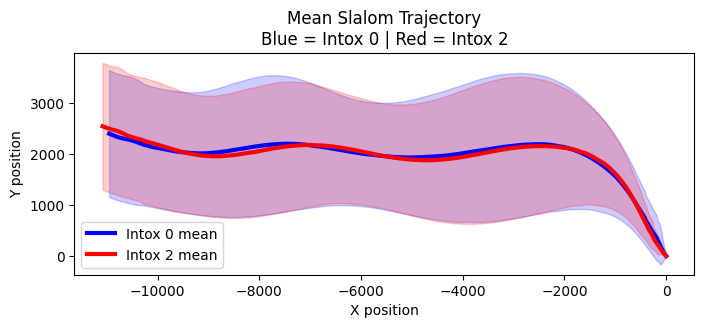

In [33]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Folder
data_folder = Path(r"C:\Users\amoh\Desktop\microtox\eventhallen\signals")

# store trajectories
traj = {0: [], 2: []}

# -----------------------------
# LOAD TRAJECTORIES
# -----------------------------
for file in data_folder.glob("*.csv"):

    name = file.stem
    parts = name.split("_")

    participant = int(parts[0][1:])
    intox = int(parts[1][1:])
    vehicle = int(parts[2][1:])
    task = parts[4]

    if vehicle != 1 or task != "slalom":
        continue

    if intox not in [0,2]:
        continue

    df = pd.read_csv(file)

    if "VOI_Frame X" not in df.columns or "VOI_Frame Y" not in df.columns:
        continue

    x = -df["VOI_Frame X"]
    y = -df["VOI_Frame Y"]

    valid = ~(x.isna() | y.isna())
    x = x[valid].values
    y = y[valid].values

    # align start
    x = x - x[0]
    y = y - y[0]

    traj[intox].append(np.vstack([x,y]).T)

# -----------------------------
# RESAMPLE TRAJECTORIES
# -----------------------------
def resample(tr, n=200):
    """Resample trajectory to fixed length"""
    t = np.linspace(0,1,len(tr))
    t_new = np.linspace(0,1,n)

    x = np.interp(t_new, t, tr[:,0])
    y = np.interp(t_new, t, tr[:,1])

    return np.vstack([x,y]).T


resampled = {0: [], 2: []}

for level in [0,2]:
    for tr in traj[level]:
        resampled[level].append(resample(tr))

# convert to arrays
T0 = np.array(resampled[0])
T2 = np.array(resampled[2])

# -----------------------------
# MEAN AND STD
# -----------------------------
mean0 = T0.mean(axis=0)
std0 = T0.std(axis=0)

mean2 = T2.mean(axis=0)
std2 = T2.std(axis=0)

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(8,6))

# sober
plt.plot(mean0[:,0], mean0[:,1], color="blue", linewidth=3, label="Intox 0 mean")
plt.fill_between(
    mean0[:,0],
    mean0[:,1]-std0[:,1],
    mean0[:,1]+std0[:,1],
    color="blue",
    alpha=0.2
)

# intoxicated
plt.plot(mean2[:,0], mean2[:,1], color="red", linewidth=3, label="Intox 2 mean")
plt.fill_between(
    mean2[:,0],
    mean2[:,1]-std2[:,1],
    mean2[:,1]+std2[:,1],
    color="red",
    alpha=0.2
)

plt.xlabel("X position")
plt.ylabel("Y position")
plt.title("Mean Slalom Trajectory\nBlue = Intox 0 | Red = Intox 2")
plt.gca().set_aspect("equal")

plt.legend()

plt.show()

In [34]:
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
)

# =============== USER SETTINGS ===============
data_folder = Path(r"C:\Users\amoh\Desktop\microtox\eventhallen\signals")

imu_columns = [
    "IMU-1 Axl.X", "IMU-1 Axl.Y", "IMU-1 Axl.Z",
    "IMU-1 Gyr.X", "IMU-1 Gyr.Y", "IMU-1 Gyr.Z",
]

fs = 10                 # Hz
window_sec = 3.0
overlap = 0.0           # IMPORTANT: no overlap
window_size = int(window_sec * fs)
step_size = int(window_size * (1 - overlap))  # equals window_size

# focus vehicle: VOI scooter
VOI_VEHICLE_CODE = 1

# sequential / detector settings
PRIOR_DRUNK = 0.10
THRESHOLD = 0.90
P_STAY = 0.995  

In [35]:
def iter_windows(df: pd.DataFrame, window_size: int, step_size: int):
    n = len(df)
    w_id = 0
    for start in range(0, n - window_size + 1, step_size):
        end = start + window_size
        yield w_id, df.iloc[start:end]
        w_id += 1


def _rms(x: np.ndarray) -> float:
    return float(np.sqrt(np.mean(x**2)))


def _band_energy(x: np.ndarray, fs: float, f_lo: float, f_hi: float) -> float:
    # simple FFT band energy (works fine for short windows)
    x = x - np.mean(x)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(len(x), d=1.0/fs)
    psd = (np.abs(X) ** 2)
    mask = (freqs >= f_lo) & (freqs <= f_hi)
    return float(psd[mask].sum())


def imu_features_for_window(wdf: pd.DataFrame, fs: float) -> dict:
    feats = {}

    # per-channel stats
    for c in imu_columns:
        x = wdf[c].to_numpy(dtype=float)
        feats[f"{c}_mean"] = float(np.mean(x))
        feats[f"{c}_std"]  = float(np.std(x))
        feats[f"{c}_rms"]  = _rms(x)
        feats[f"{c}_p2p"]  = float(np.ptp(x))
        feats[f"{c}_hfE"]  = _band_energy(x, fs, 2.0, min(4.0, fs/2 - 0.1))  # 2–4 Hz-ish

    # magnitudes
    ax = wdf["IMU-1 Axl.X"].to_numpy(float)
    ay = wdf["IMU-1 Axl.Y"].to_numpy(float)
    az = wdf["IMU-1 Axl.Z"].to_numpy(float)
    gx = wdf["IMU-1 Gyr.X"].to_numpy(float)
    gy = wdf["IMU-1 Gyr.Y"].to_numpy(float)
    gz = wdf["IMU-1 Gyr.Z"].to_numpy(float)

    a_mag = np.sqrt(ax**2 + ay**2 + az**2)
    g_mag = np.sqrt(gx**2 + gy**2 + gz**2)

    feats["acc_mag_mean"] = float(np.mean(a_mag))
    feats["acc_mag_std"]  = float(np.std(a_mag))
    feats["acc_mag_rms"]  = _rms(a_mag)
    feats["gyr_mag_mean"] = float(np.mean(g_mag))
    feats["gyr_mag_std"]  = float(np.std(g_mag))
    feats["gyr_mag_rms"]  = _rms(g_mag)

    return feats

In [36]:
def make_binary_transition(p_stay: float) -> np.ndarray:
    p_sw = 1.0 - p_stay
    return np.array([[p_stay, p_sw],
                     [p_sw,   p_stay]], dtype=float)

def hmm_forward_binary(emission_lik: np.ndarray, A: np.ndarray, prior: np.ndarray) -> np.ndarray:
    """
    emission_lik: (T,2) proportional to p(x_t|y)
    A: (2,2) transition with rows sum to 1, A[i,j]=P(y_t=j|y_{t-1}=i)
    prior: (2,)
    """
    T = emission_lik.shape[0]
    post = np.zeros((T, 2), float)

    alpha = prior * emission_lik[0]
    alpha = alpha / (alpha.sum() + 1e-12)
    post[0] = alpha

    for t in range(1, T):
        pred = post[t-1] @ A
        alpha = pred * emission_lik[t]
        post[t] = alpha / (alpha.sum() + 1e-12)

    return post

In [39]:
def build_window_df(data_folder: Path, normalize_per_file: bool = True) -> pd.DataFrame:
    records = []

    for file in data_folder.glob("*.csv"):
        name = file.stem
        parts = name.split("_")
        if len(parts) < 5:
            continue

        participant = int(parts[0][1:])    # Pxxx
        intox_level = int(parts[1][1:])    # Lx
        vehicle     = int(parts[2][1:])    # Vx
        repetition  = int(parts[3][1:])    # Rx
        task        = parts[4]             # task string

        if vehicle != VOI_VEHICLE_CODE:
            continue

        df = pd.read_csv(file)

        # column check
        missing = [c for c in imu_columns if c not in df.columns]
        if missing:
            print(f"Missing columns in {file.name}: {missing}")
            continue

        # normalize within file (optional)
        if normalize_per_file:
            df[imu_columns] = (df[imu_columns] - df[imu_columns].mean()) / (df[imu_columns].std() + 1e-6)

        # windows
        for w_id, wdf in iter_windows(df, window_size, step_size):
            feats = imu_features_for_window(wdf, fs)

            rec = {
                "participant": participant,
                "intox_level": intox_level,
                "vehicle": vehicle,
                "repetition": repetition,
                "task": task,
                "window": w_id,
                "file": file.name,
                "y_true": int(intox_level > 0),   # binary
            }
            rec.update(feats)
            records.append(rec)

    return pd.DataFrame(records)

In [40]:
def make_window_model():
    try:
        from xgboost import XGBClassifier
        base = XGBClassifier(
            n_estimators=400,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            objective="binary:logistic",
            eval_metric="logloss",
            n_jobs=-1,
            random_state=42,
        )
        # XGB doesn't need scaling, but calibration helps a lot for sequential Bayes
        model = CalibratedClassifierCV(base, method="isotonic", cv=3)
        return model
    except Exception as e:
        # fallback: scaled logistic regression + calibration
        from sklearn.linear_model import LogisticRegression
        base = Pipeline([
            ("scaler", StandardScaler()),
            ("lr", LogisticRegression(max_iter=3000, class_weight="balanced"))
        ])
        model = CalibratedClassifierCV(base, method="isotonic", cv=3)
        return model
